In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.facecolor'] = '#0e0f13'
plt.rcParams['figure.facecolor'] = '#0e0f13'
plt.rcParams['axes.edgecolor'] = '#2a2d3a'
plt.rcParams['axes.labelcolor'] = '#9aa3b8'
plt.rcParams['xtick.color'] = '#555d72'
plt.rcParams['ytick.color'] = '#555d72'
plt.rcParams['text.color'] = '#c0c8d8'
plt.rcParams['grid.color'] = '#2a2d3a'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.5

In [2]:
df = pd.read_csv('silver_prices_10y.csv')
df.head(10)

,Date,Open,High,Low,Close,Adj Close,Volume,Daily_Return,MA_20,MA_50,MA_200,Volatility_20,Year,Month,Day_of_Week,Quarter
0,2016-01-29,14.0967,14.1730,14.0304,14.1066,14.1066,6111817,NaN,NaN,NaN,NaN,NaN,2016,1,4,1
1,2016-02-01,14.1003,14.2749,13.9034,14.0778,14.0778,9584560,-0.204449,NaN,NaN,NaN,NaN,2016,2,0,1
2,2016-02-02,14.2361,14.3230,14.1288,14.2156,14.2156,13682168,0.979167,NaN,NaN,NaN,NaN,2016,2,1,1
3,2016-02-03,14.5681,14.6835,14.4236,14.5388,14.5388,19283506,2.273290,NaN,NaN,NaN,NaN,2016,2,2,1
4,2016-02-04,14.4966,14.5680,14.4084,14.4797,14.4797,6432275,-0.406125,NaN,NaN,NaN,NaN,2016,2,3,1
5,2016-02-05,14.3929,14.5269,14.2884,14.4222,14.4222,10242634,-0.397601,NaN,NaN,NaN,NaN,2016,2,4,1
6,2016-02-08,14.7281,14.7993,14.6874,14.7585,14.7585,20748419,2.331932,NaN,NaN,NaN,NaN,2016,2,0,1
7,2016-02-09,14.8449,14.9437,14.8177,14.9164,14.9164,19508791,1.070087,NaN,NaN,NaN,NaN,2016,2,1,1
8,2016-02-10,14.9020,14.9716,14.7272,14.7963,14.7963,8976012,-0.805043,NaN,NaN,NaN,NaN,2016,2,2,1
9,2016-02-11,14.9050,14.9796,14.8295,14.9042,14.9042,8020977,0.728977,NaN,NaN,NaN,NaN,2016,2,3,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2606 entries, 0 to 2605
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           2606 non-null   object 
 1   Open           2606 non-null   float64
 2   High           2606 non-null   float64
 3   Low            2606 non-null   float64
 4   Close          2606 non-null   float64
 5   Adj Close      2606 non-null   float64
 6   Volume         2606 non-null   int64  
 7   Daily_Return   2605 non-null   float64
 8   MA_20          2587 non-null   float64
 9   MA_50          2557 non-null   float64
 10  MA_200         2407 non-null   float64
 11  Volatility_20  2586 non-null   float64
 12  Year           2606 non-null   int64  
 13  Month          2606 non-null   int64  
 14  Day_of_Week    2606 non-null   int64  
 15  Quarter        2606 non-null   int64  
dtypes: float64(10), int64(5), object(1)
memory usage: 325.9+ KB


In [4]:
print(f"Shape of the dataset: {df.shape}")

Shape of the dataset: (2606, 16)


In [5]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume,Daily_Return,MA_20,MA_50,MA_200,Volatility_20,Year,Month,Day_of_Week,Quarter
count,2606.000000,2606.000000,2606.000000,2606.000000,2606.000000,2.606000e+03,2605.000000,2587.000000,2557.000000,2407.000000,2586.000000,2606.000000,2606.000000,2606.000000,2606.000000
mean,21.727639,21.886746,21.571277,21.729980,21.729980,1.187930e+07,0.041908,21.716327,21.696416,21.605722,1.480106,2020.571374,6.525326,2.000767,2.508826
std,5.663826,5.702769,5.624305,5.662620,5.662620,7.937814e+06,1.489655,5.597678,5.488435,4.958227,0.231644,2.880887,3.445759,1.414756,1.116840
min,12.355000,12.488800,12.302500,12.435900,12.435900,9.754490e+05,-4.933561,12.680500,12.967500,14.013700,0.838235,2016.000000,1.000000,0.000000,1.000000
25%,16.087125,16.204725,15.967625,16.102475,16.102475,6.502228e+06,-0.964398,16.024750,16.153400,16.184200,1.318495,2018.000000,4.000000,1.000000,2.000000
50%,22.558700,22.734600,22.416200,22.566300,22.566300,9.929313e+06,0.028722,22.701800,22.792500,23.497100,1.478072,2021.000000,7.000000,2.000000,3.000000
75%,25.617300,25.801175,25.401975,25.568625,25.568625,1.497756e+07,1.003449,25.466600,25.446200,24.779700,1.635742,2023.000000,10.000000,3.000000,4.000000
max,35.400900,35.733500,34.999200,35.359300,35.359300,8.499349e+07,5.761538,34.027100,33.458500,32.114000,2.424404,2026.000000,12.000000,4.000000,4.000000


In [6]:
print(f"Null values in the dataset: {df.isnull().sum()}")

Null values in the dataset: Date               0
Open               0
High               0
Low                0
Close              0
Adj Close          0
Volume             0
Daily_Return       1
MA_20             19
MA_50             49
MA_200           199
Volatility_20     20
Year               0
Month              0
Day_of_Week        0
Quarter            0
dtype: int64


In [13]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
print(f"Date range: {df['Date'].min().date()} -> {df['Date'].max().date()}")

Date range: 2016-01-29 -> 2026-01-23


In [14]:
info = pd.DataFrame({
    'dtype': df.dtypes,
    'null_count':df.isnull().sum(),
    'null_pct': (df.isnull().sum() / len(df) * 100).round(2)
})
print(info)

                        dtype  null_count  null_pct
Date           datetime64[ns]           0      0.00
Open                  float64           0      0.00
High                  float64           0      0.00
Low                   float64           0      0.00
Close                 float64           0      0.00
Adj Close             float64           0      0.00
Volume                  int64           0      0.00
Daily_Return          float64           1      0.04
MA_20                 float64          19      0.73
MA_50                 float64          49      1.88
MA_200                float64         199      7.64
Volatility_20         float64          20      0.77
Year                    int64           0      0.00
Month                   int64           0      0.00
Day_of_Week             int64           0      0.00
Quarter                 int64           0      0.00


In [15]:
df[['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return', 'Volatility_20']].describe().round(0)

,Open,High,Low,Close,Volume,Daily_Return,Volatility_20
count,2606.0,2606.0,2606.0,2606.0,2606.0,2605.0,2586.0
mean,22.0,22.0,22.0,22.0,11879297.0,0.0,1.0
std,6.0,6.0,6.0,6.0,7937814.0,1.0,0.0
min,12.0,12.0,12.0,12.0,975449.0,-5.0,1.0
25%,16.0,16.0,16.0,16.0,6502228.0,-1.0,1.0
50%,23.0,23.0,22.0,23.0,9929313.0,0.0,1.0
75%,26.0,26.0,25.0,26.0,14977555.0,1.0,2.0
max,35.0,36.0,35.0,35.0,84993489.0,6.0,2.0


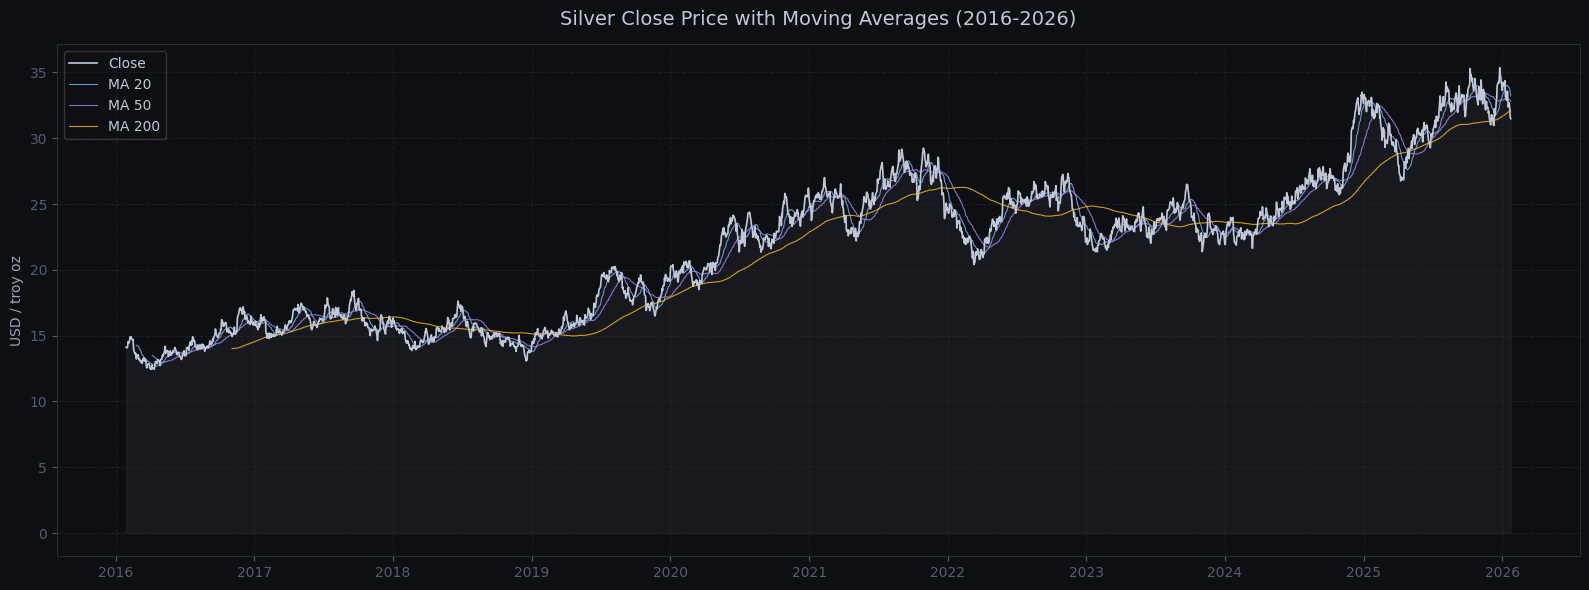

In [18]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(df['Date'], df['Close'], color='#c0c8d8', linewidth=1.2, label='Close', zorder=3)
ax.plot(df['Date'], df['MA_20'],  color='#7eb8f7', linewidth=0.8, alpha=0.8, label='MA 20')
ax.plot(df['Date'], df['MA_50'],  color='#a78bfa', linewidth=0.8, alpha=0.8, label='MA 50')
ax.plot(df['Date'], df['MA_200'], color='#fbbf24', linewidth=0.8, alpha=0.8, label='MA 200')

ax.fill_between(df['Date'], df['Close'], alpha=0.06, color='#c0c8d8')
ax.set_title('Silver Close Price with Moving Averages (2016-2026)', fontsize=14, pad=14)
ax.set_ylabel('USD / troy oz')
ax.legend(loc='upper left', framealpha=0.2)
ax.grid(True)
plt.tight_layout()
plt.savefig('moving_avg.png')
plt.show()

In [17]:
annual = df.groupby("Year").agg(
    Open_first   = ('Open',  'first'),
    Close_last   = ('Close', 'last'),
    High_max     = ('High',  'max'),
    Low_min      = ('Low',   'min'),
    Avg_Volume   = ('Volume','mean'),
    Trading_Days = ('Date',  'count')
).reset_index()
annual['Annual_Return_pct'] = ((annual['Close_last'] - annual['Open_first']) / annual['Open_first'] * 100).round(2)
annual['Price_Range'] = (annual['High_max'] - annual['Low_min']).round(2)
print(annual.to_string(index=False))

 Year  Open_first  Close_last  High_max  Low_min   Avg_Volume  Trading_Days  Annual_Return_pct  Price_Range
 2016     14.0967     15.8248   17.3286  12.3025 1.239292e+07           241              12.26         5.03
 2017     15.7211     15.8744   18.5280  14.5540 1.243437e+07           260               0.98         3.97
 2018     16.3676     13.7987   17.7576  13.0158 1.199554e+07           261             -15.70         4.74
 2019     14.3682     19.1316   20.5146  14.2539 1.216033e+07           261              33.15         6.26
 2020     19.8002     25.9009   26.4086  18.3448 1.174440e+07           262              30.81         8.06
 2021     25.5057     24.7122   29.5152  22.0553 1.173596e+07           261              -3.11         7.46
 2022     24.4986     22.1003   27.6381  20.2561 1.160016e+07           260              -9.79         7.38
 2023     22.3375     22.7551   26.8234  21.1020 1.126090e+07           260               1.87         5.72
 2024     21.9304     32.653

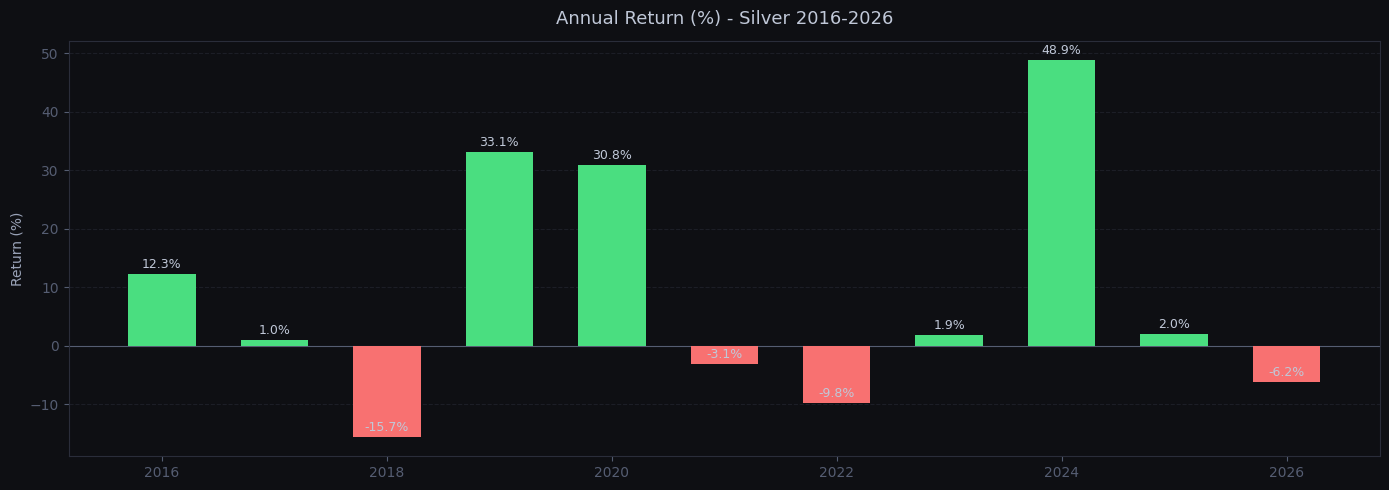

In [19]:
colors = ['#4ade80' if x >= 0 else '#f87171' for x in annual['Annual_Return_pct']]
fig, ax = plt.subplots(figsize=(14,5))
bars = ax.bar(annual['Year'], annual['Annual_Return_pct'], color=colors, width=0.6, zorder=3)
ax.axhline(0, color='#555d72', linewidth=0.8)
ax.set_title('Annual Return (%) - Silver 2016-2026', fontsize=13, pad=12)
ax.set_ylabel('Return (%)')
ax.grid(True, axis='y')

for bar, val in zip(bars, annual['Annual_Return_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, color='#c0c8d8')

plt.tight_layout()
plt.savefig('annual_return.png')
plt.show()

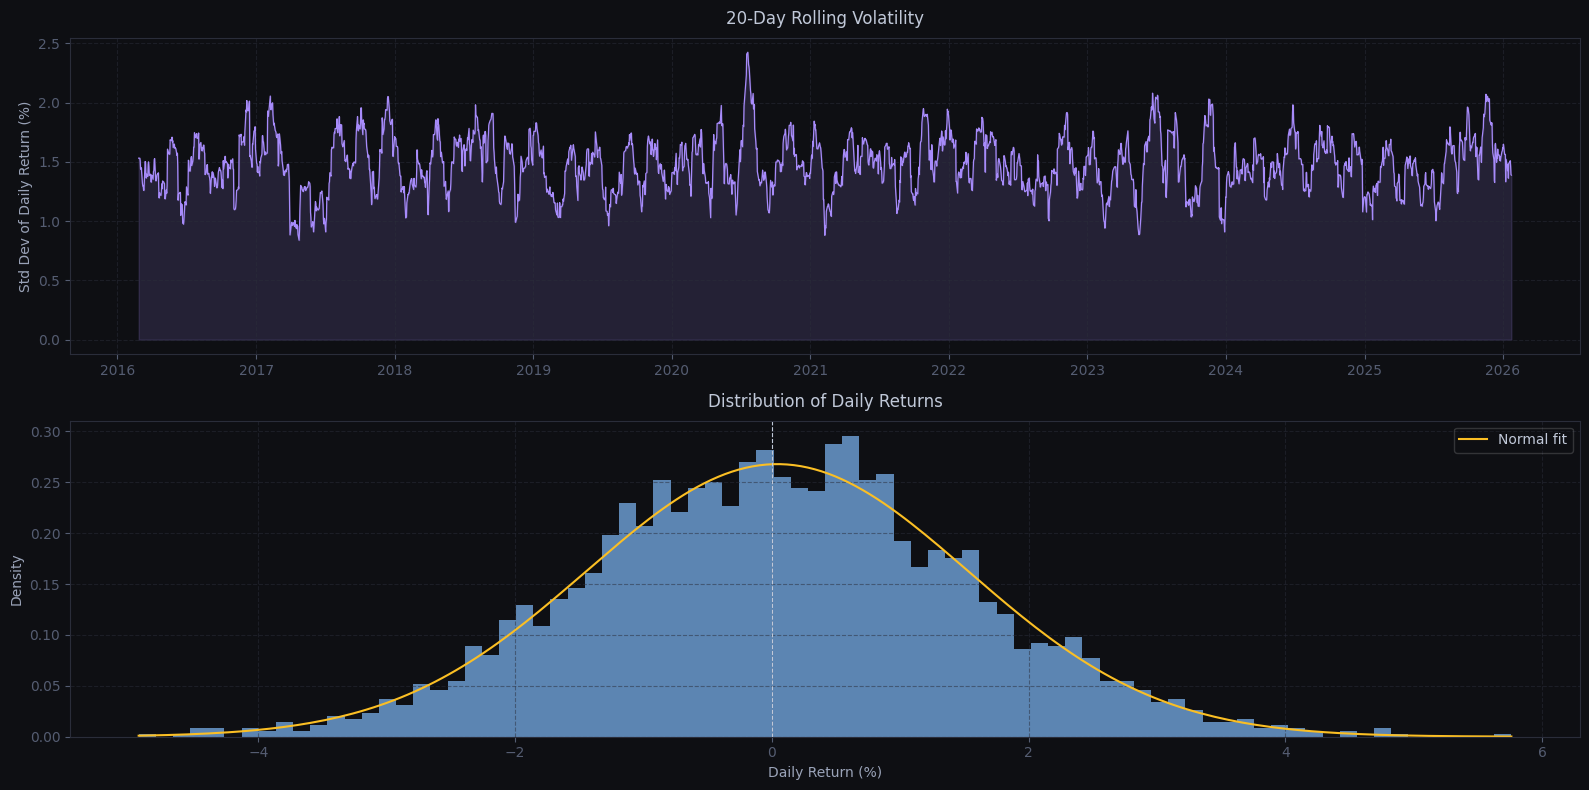

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=False)

axes[0].plot(df['Date'], df['Volatility_20'], color='#a78bfa', linewidth=0.9)
axes[0].fill_between(df['Date'], df['Volatility_20'], alpha=0.15, color='#a78bfa')
axes[0].set_title('20-Day Rolling Volatility', fontsize=12, pad=10)
axes[0].set_ylabel('Std Dev of Daily Return (%)')
axes[0].grid(True)

ret = df['Daily_Return'].dropna()
axes[1].hist(ret, bins=80, color='#7eb8f7', alpha=0.7, edgecolor='none', density=True)
x = np.linspace(ret.min(), ret.max(), 200)
axes[1].plot(x, stats.norm.pdf(x, ret.mean(), ret.std()), color='#fbbf24', linewidth=1.5, label='Normal fit')
axes[1].axvline(0, color='#c0c8d8', linewidth=0.8, linestyle='--')
axes[1].set_title('Distribution of Daily Returns', fontsize=12, pad=10)
axes[1].set_xlabel('Daily Return (%)')
axes[1].set_ylabel('Density')
axes[1].legend(framealpha=0.2)
axes[1].grid(True)

plt.tight_layout()
plt.savefig('Rolling_volatility.png')
plt.show()

In [22]:
ret = df['Daily_Return'].dropna()
print(f"Mean daily return   : {ret.mean():.4f}%")
print(f"Std deviation       : {ret.std():.4f}%")
print(f"Skewness            : {ret.skew():.4f}")
print(f"Kurtosis (excess)   : {ret.kurt():.4f}")
print(f"Best day            : +{ret.max():.2f}% on {df.loc[ret.idxmax(), 'Date'].date()}")
print(f"Worst day           : {ret.min():.2f}% on {df.loc[ret.idxmin(), 'Date'].date()}")

Mean daily return   : 0.0419%
Std deviation       : 1.4897%
Skewness            : 0.0442
Kurtosis (excess)   : 0.0701
Best day            : +5.76% on 2016-11-17
Worst day           : -4.93% on 2017-01-31


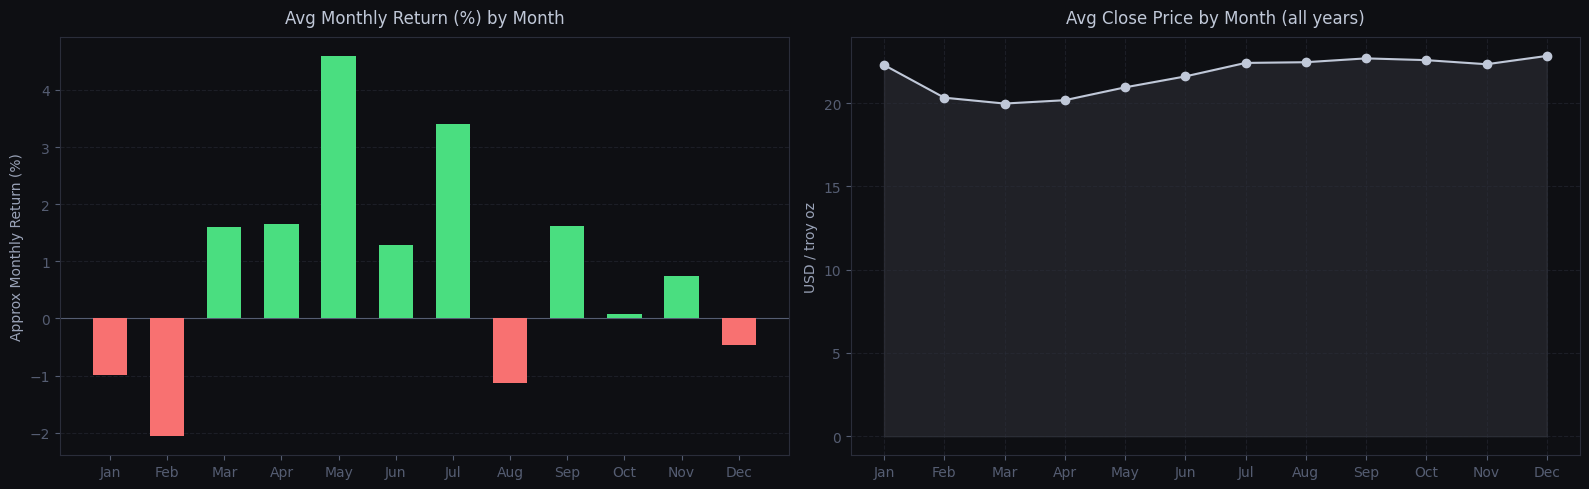

In [23]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

monthly_ret = df.groupby('Month')['Daily_Return'].mean() * 21
monthly_close = df.groupby('Month')['Close'].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors_ret = ['#4ade80' if x >= 0 else '#f87171' for x in monthly_ret]
axes[0].bar(month_names, monthly_ret.values, color=colors_ret, width=0.6, zorder=3)
axes[0].axhline(0, color='#555d72', linewidth=0.8)
axes[0].set_title('Avg Monthly Return (%) by Month', fontsize=12, pad=10)
axes[0].set_ylabel('Approx Monthly Return (%)')
axes[0].grid(True, axis='y')

axes[1].plot(month_names, monthly_close.values, color='#c0c8d8', marker='o', linewidth=1.5)
axes[1].fill_between(range(12), monthly_close.values, alpha=0.1, color='#c0c8d8')
axes[1].set_title('Avg Close Price by Month (all years)', fontsize=12, pad=10)
axes[1].set_ylabel('USD / troy oz')
axes[1].set_xticks(range(12))
axes[1].set_xticklabels(month_names)
axes[1].grid(True)
plt.tight_layout()
plt.savefig('monthly_return_and_avg.png')
plt.show()

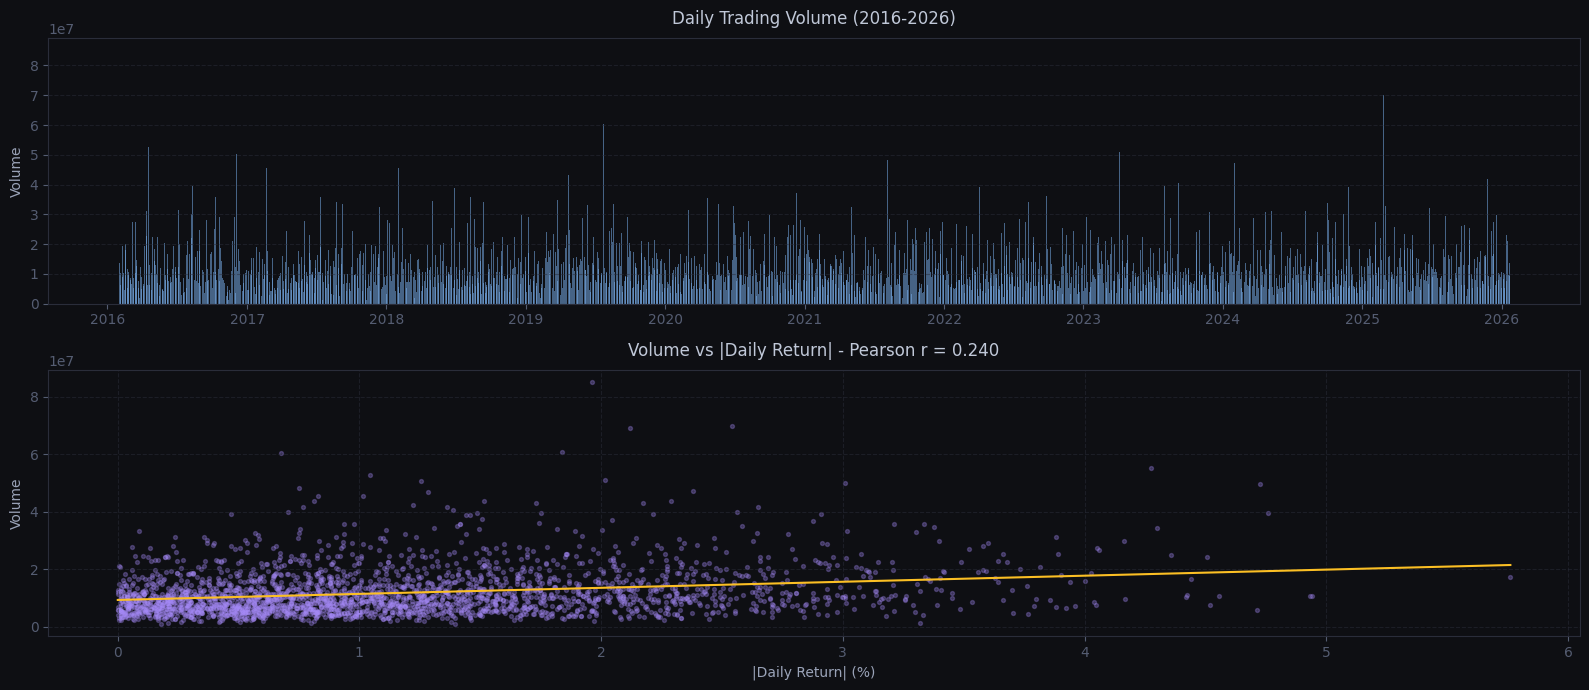

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(16, 7))

axes[0].bar(df['Date'], df['Volume'], color='#7eb8f7', alpha=0.5, width=1.5)
axes[0].set_title('Daily Trading Volume (2016-2026)', fontsize=12, pad=10)
axes[0].set_ylabel('Volume')
axes[0].grid(True, axis='y')

vol_corr = df[['Volume','Daily_Return']].dropna().copy()
vol_corr['Abs_Return'] = vol_corr['Daily_Return'].abs()
axes[1].scatter(vol_corr['Abs_Return'], vol_corr['Volume'],
                alpha=0.3, s=8, color='#a78bfa')
m, b, r, p, _ = stats.linregress(vol_corr['Abs_Return'], vol_corr['Volume'])
x_line = np.linspace(vol_corr['Abs_Return'].min(), vol_corr['Abs_Return'].max(), 100)
axes[1].plot(x_line, m*x_line + b, color='#fbbf24', linewidth=1.5)
axes[1].set_title(f'Volume vs |Daily Return| - Pearson r = {r:.3f}', fontsize=12, pad=10)
axes[1].set_xlabel('|Daily Return| (%)')
axes[1].set_ylabel('Volume')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('Volume_analysis.png')
plt.show()

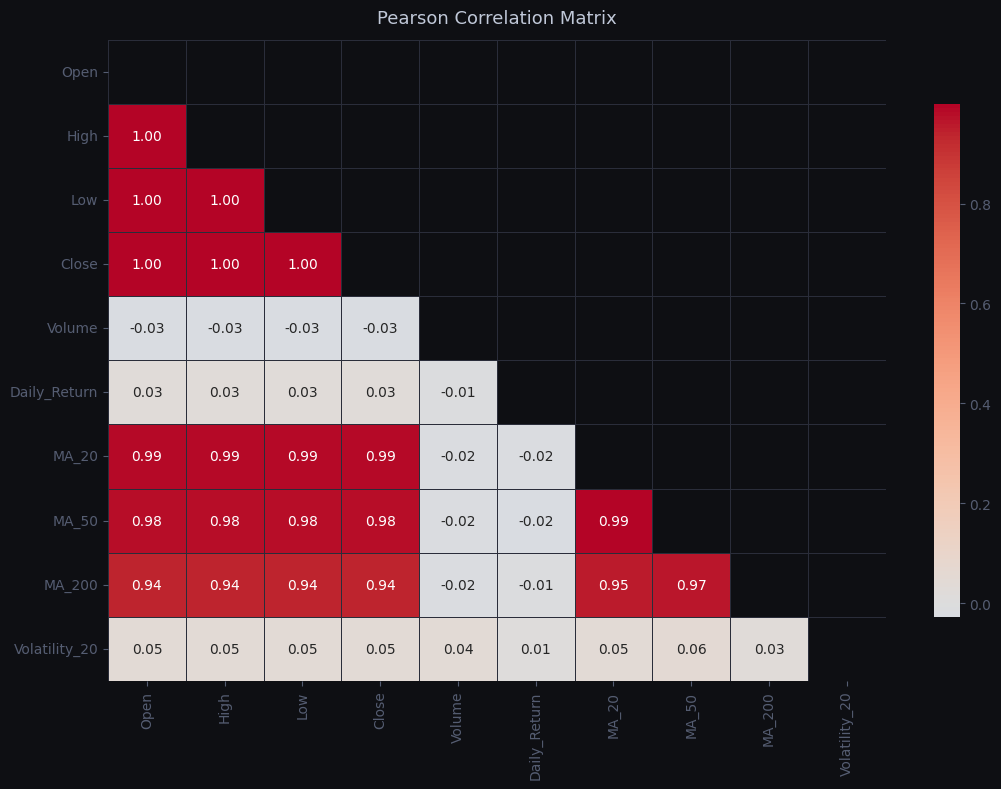

In [25]:
numeric_cols = ['Open','High','Low','Close','Volume','Daily_Return',
                'MA_20','MA_50','MA_200','Volatility_20']

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, linecolor='#2a2d3a',
            ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Pearson Correlation Matrix', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('Correlation_matrix.png')
plt.show()